## Batched Grid-based Sorting for Colors and Images with ShuffleSoftSort 
This notebook demonstrates the Gradient-based Sorting (ShuffleSoftSort)from the paper:
<div style="text-align: center"> 
<H3>"Permutation Learning with Only N Parameters: <br> From SoftSort to Self-Organizing Gaussians"</H3>
<p style='text-align: center;'> Kai Barthel, Florian Tim Barthel, Peter Eisert 
    <br>
 Visual Computing Group HTW Berlin and Fraunhofer HHI</p>
<br>
<p>
This notebook reads an image with the colors of the pixels (serving as a color set) or reads a folder with images and then sorts the colors or the images by similarity. This notebook uses batch processing limiting memory to O(batch_size × N).
    
To measure the quality of a vector sorting, we use a **scale-invariant metric** that compares the average squared distance between neighboring vectors in the sorted grid to the average squared distance of the entire dataset. A value of **1** means the grid is as random as the original data, and a smaller value indicates better sorting. For a more precise measure, the **Distance Preservation Quality (DPQ)** can be used, with a value of **1** represents a perfect and **0** a random sorting.
    
To run this notebook, you need to unzip the included data.zip file. <br>For this notebook, the number of images to be sorted needs to be a square number.

 ## 1. Configuration & Setup

In [1]:
# imports
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random
import re
from pathlib import Path
from PIL import Image
from dataclasses import dataclass, field
from typing import Tuple, Optional

torch.set_printoptions(precision=1, threshold=None, edgeitems=10, linewidth=250, profile=None, sci_mode=False)

In [2]:
@dataclass
class Config:
    """Configuration settings for the sorting experiment."""
    # --- Data Sets: choose from
    #     image sets: "signs", "kitchen", "web" or
    #     color sets: "colors_256_random.png", "colors_1024_random.png" or
    #     random colors: "rand_y_x": RGB colors with y rows and x columns
    data_set: str = "kitchen" # "colors_1024_random.png" # "rgb_4x4_2D.png" # "kitchen" # "gray_8_1D_swap.png"    "colors_4096_random.png" #   "colors_64_random.png" #
    data_path: str = "../data/"
    sort_images: bool = False
    use_paper_feature_vectors = True
    shuffle_input: bool = True
    nx, ny = 0, 0

    seed: int = 1 
    learning_rate: float = 0.3
    iterations: int = 4
    runs: int = 1000
    batch_size = 32   #  nx * ny has to be a multiple of batch_size

    l_constraint: float = 0
    l_std: float = 1.5  # 2

    tau_start: float = 1 # 0.5 # 1
    tau_end: float = 0.1   # 0.1
    tau_pow: float = 1.0

    log_every: int = 100

    device: torch.device = field(default_factory=lambda: torch.device("cuda" if torch.cuda.is_available() else "cpu"))


### 2: Data Loading

In [3]:
def load_data(cfg: Config) -> Tuple[torch.Tensor, Optional[np.ndarray]]:
    set_global_seed(cfg.seed)

    m = re.match(r"^rand_(\d+)_(\d+)$", cfg.data_set)
    if m:
        height = int(m.group(1))
        width = int(m.group(2))
        vectors = (255 * np.random.rand(height * width, 3)).astype(np.uint8).astype(np.float32)
        image_files = None
    else:
        if ".png" in cfg.data_set:
            image_path = Path(cfg.data_path) / cfg.data_set
            image = Image.open(image_path).convert("RGB")
            width, height = image.size
            vectors = np.array(image.getdata()).reshape((-1, 3)).astype(np.float32)
            image_files = None
            print(f"Loaded {width * height} color vectors from '{image_path}'.")
        else:
            cfg.sort_images = True
            set_folder = Path(cfg.data_path) / cfg.data_set
            image_files = sorted([str(f) for f in set_folder.rglob('*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png']])
            image_files = np.array(image_files)
            if cfg.use_paper_feature_vectors:
                vector_dir = set_folder / "vectors"
                vectors = np.array([np.load(vector_dir / f"{Path(f).stem}.npy") for f in image_files]).astype(np.float32)
                n = vectors.shape[0]
                print(f"Loaded {n} feature vectors from '{set_folder}'.")
            else:
                vectors = create_vectors_from_thumbnails(image_files, thumb_size=4).astype(np.float32)
                n = vectors.shape[0]
                print(f"Calculated {n} feature vectors from thumbnails.")
            height = width = int(n ** 0.5)
            if height * width != n:
                raise ValueError("Only image sets with a square number of images are supported.")
    if cfg.shuffle_input:
        np.random.shuffle(vectors)
        if cfg.sort_images:
            set_global_seed(cfg.seed)
            np.random.shuffle(image_files)

    cfg.ny, cfg.nx = height, width
    if cfg.ny * cfg.nx == 0:
        print("No data to sort available!")
        exit(1)
    return torch.from_numpy(vectors), image_files

In [4]:
def create_vectors_from_thumbnails(image_files, thumb_size=4):
    n_images = len(image_files)
    feature_vectors = np.zeros((n_images, thumb_size * thumb_size * 3))
    for i in range(n_images):
        file = image_files[i]
        im = Image.open(file)
        im.thumbnail((thumb_size, thumb_size), Image.Resampling.BOX)
        pixels = np.array(im) / 255
        pixels = pixels.reshape((thumb_size * thumb_size * 3))
        feature_vectors[i] = pixels
    return feature_vectors

## 3: The SoftSort Network (weights only)

In [5]:
class Batched_ShuffleSoftSort_Network(nn.Module):
    """Vectorized: parameterizes soft permutations for G groups of size K."""

    def __init__(self, G: int, K: int):
        super().__init__()
        init = torch.arange(K, dtype=torch.float32).repeat(G, 1)
        self.weights = nn.Parameter(init)

    def forward(self, tau: float = 1.0) -> torch.Tensor:
        # w: (G, K, 1)
        w_col = self.weights.unsqueeze(-1)
        # sorted positions per group
        w_sorted = torch.sort(w_col, dim=1)[0].transpose(1, 2)  # (G, 1, K)
        pairwise_diff = -(w_col - w_sorted).abs() / tau  # (G, K, K)
        P_hat = pairwise_diff.softmax(dim=-1)
        return P_hat  # (G, K, K)

## 4: Loss Functions

In [6]:
def get_mean_neighbor_dist(vectors: torch.Tensor, ny: int, nx: int) -> torch.Tensor:
    grid = vectors.view(ny, nx, -1)
    diff_h = grid[:, :-1, :] - grid[:, 1:, :]
    diff_v = grid[:-1, :, :] - grid[1:, :, :]
    sum_sq_h = torch.sum(diff_h ** 2)
    sum_sq_v = torch.sum(diff_v ** 2)
    num_pairs = (nx - 1) * ny + (ny - 1) * nx
    return (sum_sq_h + sum_sq_v) / num_pairs

In [7]:
def permutation_constraint_loss(perm_matrix: torch.Tensor) -> torch.Tensor:
    if perm_matrix.dim() == 3:
        return torch.mean((perm_matrix.sum(dim=1) - 1) ** 2) 
    else:
        return torch.mean((perm_matrix.sum(dim=0) - 1) ** 2)

In [8]:
def calculate_total_loss(alpha, perm_soft: torch.Tensor, x_sort_soft: torch.Tensor, expected_stats: dict, cfg: Config) -> dict:
    loss_neighbors = get_mean_neighbor_dist(x_sort_soft, cfg.ny, cfg.nx) / expected_stats['mean_dist']
    loss_constraint = cfg.l_constraint * permutation_constraint_loss(perm_soft)

    std_x_sort_soft = torch.std(x_sort_soft, dim=0, unbiased=False)  ### torch.std
    loss_std = cfg.l_std * torch.abs(expected_stats['std'] - std_x_sort_soft).sum() / expected_stats['std'].sum()

    total = loss_neighbors + loss_std + loss_constraint # + loss_perm
    return {'total': total, 'neighbors': loss_neighbors, 'std': loss_std, 'constraint': loss_constraint}

## 5: Helper & Utility Functions

In [9]:
def set_global_seed(seed: int):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    
    
def shuffle_numbers_with_degree(N: int, degree: float, device) -> torch.Tensor:
    arr = torch.arange(N, device=device, dtype=torch.int32)
    if degree == 0.0:
        return arr
    if degree >= 1.0:
        return arr[torch.randperm(N, device=device)]
    max_shift = int(degree * N)
    noise = max_shift * torch.rand((N,), device=device)
    
    perturbed = arr + noise
    _, perm = torch.sort(perturbed)
    return perm
    
    
def visualize_result(sorted_vectors: torch.Tensor, ny: int, nx: int, title: str, sorted_files: Optional[np.ndarray] = None):
    fig = plt.figure(figsize=(6, 6))
    plt.title(title, fontsize=12)
    plt.axis('off')
    if sorted_files is not None:
        pixels_per_image = 128
        collage = np.zeros((pixels_per_image * ny, pixels_per_image * nx, 3))
        reshaped_files = np.array(sorted_files).reshape((ny, nx))
        for i in range(ny):
            for j in range(nx):
                with Image.open(reshaped_files[i, j]) as im:
                    im.thumbnail((pixels_per_image, pixels_per_image), Image.Resampling.LANCZOS)
                    pixels = np.array(im.convert("RGB")) / 255.0
                    collage[i * pixels_per_image:(i + 1) * pixels_per_image,
                            j * pixels_per_image:(j + 1) * pixels_per_image] = pixels
        plt.imshow(collage)
    else:
        img = sorted_vectors.detach().cpu().numpy().astype(np.uint8).reshape(ny, nx, -1)
        plt.imshow(img)
    plt.show()

## Distance Preservation Metric

In [12]:
def squared_l2_distance(q, p):
    ps = torch.sum(p * p, axis=1, keepdim=True)
    qs = torch.sum(q * q, axis=1, keepdim=True)
    p_q_transpose = torch.matmul(p, q.transpose(0, 1))

    squared_dists = ps - 2 * p_q_transpose + qs.transpose(0, 1)
    return squared_dists

''' Converts a given gridshape to a grid index matrix
    and calculates the squared spatial distances '''
def compute_spatial_distances_for_grid(grid_shape, wrap):
    if wrap:
        return compute_spatial_distances_for_grid_wrapped(grid_shape)
    else:
        return compute_spatial_distances_for_grid_non_wrapped(grid_shape)

def compute_spatial_distances_for_grid_wrapped(grid_shape):
    n_x = grid_shape[0]
    n_y = grid_shape[1]

    wrap1 = [[0, 0], [0, 0], [0, 0], [0, n_y], [0, n_y], [n_x, 0], [n_x, 0], [n_x, n_y]]
    wrap2 = [[0, n_y], [n_x, 0], [n_x, n_y], [0, 0], [n_x, 0], [0, 0], [0, n_y], [0, 0]]

    # create 2D position matrix with tuples, i.e. [(0,0), (0,1)...(H-1, W-1)]
    a, b = np.indices(grid_shape)
    mat = np.concatenate([np.expand_dims(a, -1), np.expand_dims(b, -1)], axis=-1)
    mat_flat = mat.reshape((-1, 2))

    # use this 2D matrix to calculate spatial distances between on positions on the grid
    d = squared_l2_distance(mat_flat, mat_flat)
    for i in range(8):
        # look for smaller distances with wrapped coordinates
        d_i = squared_l2_distance(mat_flat + wrap1[i], mat_flat + wrap2[i])
        d = np.minimum(d, d_i)

    return d

def compute_spatial_distances_for_grid_non_wrapped(grid_shape):
    # create 2D position matrix with tuples, i.e. [(0,0), (0,1)...(H-1, W-1)]
    a, b = torch.tensor(np.indices(grid_shape))
    a, b = a.type(torch.FloatTensor), b.type(torch.FloatTensor)
    mat = torch.cat([a[:, :, None], b[:, :, None]], axis=-1)
    mat_flat = mat.view((-1, 2))

    # use this 2D matrix to calculate spatial distances between on positions on the grid
    d = squared_l2_distance(mat_flat, mat_flat)
    return d

''' Sort the HD distances by the 2D distance on the grid '''
def sort_hddists_by_2d_dists_fast(hd_dists, ld_dists, device):
    hd_dists = hd_dists.type(torch.FloatTensor).to(device)
    max_hd_dist = torch.max(hd_dists) * 1.0001

    ld_hd_dists = (hd_dists / max_hd_dist + ld_dists).to(
        device)  # add the normed HD distances (0 .. 0.999) to the 2D integer distances
    ld_hd_dists = torch.sort(ld_hd_dists)[0]  # then a normal sorting of the rows can be used

    sorted_HD_D = torch.fmod(ld_hd_dists, 1) * max_hd_dist

    return sorted_HD_D

''' computes the Distance Preservation Gain delta DP_k(S) '''
def get_distance_preservation_gain(sorted_d_mat, d_mean, device):
    # range of numbers [1, K], with K = N-1
    nums = torch.arange(1, len(sorted_d_mat)).to(device)

    # compute cumulative sum of neighbor distance values for all rows, shape = (N, K)
    cumsum = torch.cumsum(sorted_d_mat[:, 1:], axis=1)

    # compute average of neighbor distance values for all rows, shape = (N, K)
    d_k = cumsum / nums

    # compute average of all rows for each k, shape = (K, )
    d_k = d_k.mean(axis=0)

    # compute Distance Preservation Gain and set negative values to 0, shape = (K, )
    # d_k = torch.maximum((d_mean - d_k) / d_mean, torch.tensor0)
    d_k = torch.clip((d_mean - d_k) / d_mean, 0, 1)
    return d_k

''' computes the Distance Preservation Quality DPQ_p(S) '''
def dpq(sorted_X, device, p=2, wrap=False):
    # setup of required variables
    grid_shape = sorted_X.shape[:-1]
    dim = sorted_X.shape[-1]
    N = np.prod(grid_shape)

    # compute matrix of Euclidean distances in the high dimensional space
    dists_HD = torch.cdist(sorted_X.reshape(-1, dim), sorted_X.reshape(-1, dim), p=2)

    # sort HD distance matrix rows in acsending order (first value is always 0 zero now)
    sorted_D = torch.sort(dists_HD, -1)[0]

    # compute the expected value of the HD distance matrix
    mean_D = torch.mean(sorted_D[:, 1:])

    # compute spatial distance matrix for each position on the 2D grid (squared for integer dists)
    dists_spatial = compute_spatial_distances_for_grid(grid_shape, wrap).to(device)

    # sort rows of HD distances by the values of spatial distances
    sorted_HD_by_2D = sort_hddists_by_2d_dists_fast(dists_HD, dists_spatial, device)

    # get delta DP_k values
    delta_DP_k_2D = get_distance_preservation_gain(sorted_HD_by_2D, mean_D, device)
    delta_DP_k_HD = get_distance_preservation_gain(sorted_D, mean_D, device)

    # compute p norm of DP_k values
    normed_delta_D_2D_k = torch.linalg.norm(delta_DP_k_2D, ord=p)
    normed_delta_D_HD_k = torch.linalg.norm(delta_DP_k_HD, ord=p)

    # DPQ(s) is the ratio between the two normed DP_k values
    DPQ = normed_delta_D_2D_k / normed_delta_D_HD_k

    return DPQ

##  6: Group-wise Sorting

In [10]:
def perform_sorting(x: torch.Tensor, image_files: Optional[np.ndarray], cfg: Config) -> Tuple[torch.Tensor, np.ndarray]:
    n = x.shape[0]
    ny, nx = cfg.ny, cfg.nx
    K = cfg.batch_size
    G = n // K
    assert n == K * G, "Only grids with N = K * G are supported."

    device = cfg.device
    x = x.to(device)
    indices = torch.arange(n, device=device)

    # Precompute stats
    var_x = torch.var(x, dim=0, unbiased=True)
    expected_stats = {
        "mean_dist": 2 * var_x.sum(),
        "std": var_x.sqrt(),
    }

    for run in range(cfg.runs + 1):
        tau = cfg.tau_start * (cfg.tau_end / cfg.tau_start) ** ((run / cfg.runs) ** cfg.tau_pow)

        alpha = run / cfg.runs
        degree = 1.05 - alpha
        shuf_idx = shuffle_numbers_with_degree(n, degree, device)

        if ny == nx and run % 2 == 0:
            shuf_y = shuf_idx // nx
            shuf_x = shuf_idx % nx
            shuf_T = shuf_x * nx + shuf_y
            shuf_idx = shuf_T.reshape((nx, ny)).T.flatten()

        x_shuf = x[shuf_idx]
        indices_shuf = indices[shuf_idx]

        x_groups = x_shuf.view(G, K, -1)   # (G, K, feat)
        idx_groups = indices_shuf.view(G, K)  # (G, K)

        net = Batched_ShuffleSoftSort_Network(G, K).to(device)
        optimizer = torch.optim.Adam(net.parameters(), lr=cfg.learning_rate)

        it = 0
        while True:
            it += 1
            optimizer.zero_grad()

            perm_blocks = net(tau)  # (G, K, K)
            x_groups_soft = torch.bmm(perm_blocks, x_groups)  # (G, K, feat_dim)
            x_shuf_soft = x_groups_soft.reshape(n, -1)

            x_sort_soft_unshuffled = torch.empty_like(x_shuf_soft)
            x_sort_soft_unshuffled[shuf_idx] = x_shuf_soft

            # argmax per row for each block
            sort_idx = perm_blocks.argmax(dim=-1)  # (G, K)
            num_duplicates = n - torch.unique(sort_idx, dim=-1).numel()

            if num_duplicates == 0 and it >= cfg.iterations:
                with torch.no_grad():
                    batch_idx = torch.arange(G, device=device)[:, None]
                    x_sorted   = x_groups[batch_idx, sort_idx].reshape(n, -1)
                    indices_sorted = idx_groups[batch_idx, sort_idx].reshape(n)

                    # Undo shuffle
                    x_new = torch.empty_like(x_sorted)
                    x_new[shuf_idx] = x_sorted
                    indices_new = torch.empty_like(indices_sorted)
                    indices_new[shuf_idx] = indices_sorted
                break

            losses = calculate_total_loss(alpha, perm_blocks, x_sort_soft_unshuffled, expected_stats, cfg)
            losses["total"].backward()
            optimizer.step()

        x = x_new
        indices = indices_new

        if run % cfg.log_every == 0:
            hard_dist = get_mean_neighbor_dist(x, ny, nx) / expected_stats["mean_dist"]
            print(
                f"Run: {run:4d}  | τ: {tau:.3f} | "
                f"L: {losses['total']:.3f} (nbr: {losses['neighbors']:.3f}, "
                f"std: {losses['std']:.3f}, cons: {losses['constraint']:.3f}) | "
                f"Dist ratio: {hard_dist:.3f}"
            )

    return x, indices

## 8. Main Execution Block

Starting experiment on device: cpu with seed: 1
Loaded 256 feature vectors from '../data/kitchen'.
--- Starting Optimization ---
Run:    0  | τ: 1.000 | L: 0.946 (nbr: 0.285, std: 0.661, cons: 0.000) | Dist ratio: 0.927
Run:  100  | τ: 0.794 | L: 0.843 (nbr: 0.316, std: 0.527, cons: 0.000) | Dist ratio: 0.796
Run:  200  | τ: 0.631 | L: 0.712 (nbr: 0.320, std: 0.392, cons: 0.000) | Dist ratio: 0.647
Run:  300  | τ: 0.501 | L: 0.650 (nbr: 0.348, std: 0.302, cons: 0.000) | Dist ratio: 0.595
Run:  400  | τ: 0.398 | L: 0.571 (nbr: 0.360, std: 0.212, cons: 0.000) | Dist ratio: 0.520
Run:  500  | τ: 0.316 | L: 0.497 (nbr: 0.363, std: 0.135, cons: 0.000) | Dist ratio: 0.478
Run:  600  | τ: 0.251 | L: 0.435 (nbr: 0.350, std: 0.084, cons: 0.000) | Dist ratio: 0.425
Run:  700  | τ: 0.200 | L: 0.385 (nbr: 0.335, std: 0.050, cons: 0.000) | Dist ratio: 0.367
Run:  800  | τ: 0.158 | L: 0.341 (nbr: 0.311, std: 0.030, cons: 0.000) | Dist ratio: 0.326
Run:  900  | τ: 0.126 | L: 0.333 (nbr: 0.307, std: 0

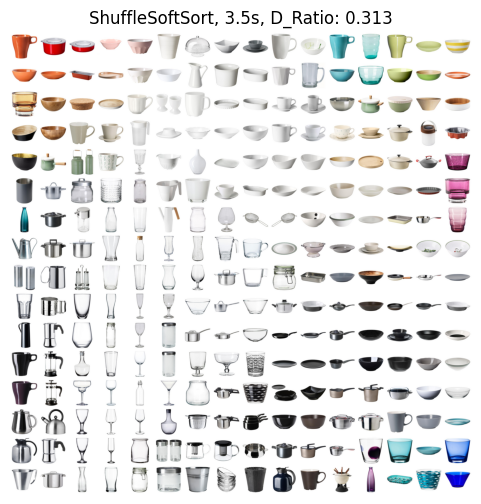

In [11]:
cfg = Config()
print(f"Starting experiment on device: {cfg.device} with seed: {cfg.seed}")

vectors, image_files = load_data(cfg)

# initial_d_ratio = get_mean_neighbor_dist(vectors, cfg.ny, cfg.nx) / (2 * torch.var(vectors, dim=0).sum())
# visualize_result(vectors, cfg.ny, cfg.nx, title=f"Initial order (Dist ratio: {initial_d_ratio:.3f})", sorted_files=image_files)

print("--- Starting Optimization ---")
start_time = time.time()
sorted_vectors, sorted_indices = perform_sorting(vectors, image_files, cfg)
duration = time.time() - start_time

final_files = image_files[sorted_indices] if cfg.sort_images else None
d_ratio = get_mean_neighbor_dist(sorted_vectors, cfg.ny, cfg.nx) / (2 * torch.var(vectors, dim=0).sum())
dpq_16 = dpq(sorted_vectors.view(cfg.ny,cfg.nx,-1), p=16, device=cfg.device)

print(f"--- Finished in {duration:.1f} seconds, D_ratio: {d_ratio:.3f} DPQ: {dpq_16:.3f}")

    visualize_result(sorted_vectors, cfg.ny, cfg.nx, title=f"ShuffleSoftSort, {duration:.1f}s, D_Ratio: {d_ratio:.3f}, DPQ: {dpq_16:.3f}", sorted_files=final_files)
    